# Pindar

In [1]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

## Chronology dictionary

First, a dict of all the datings in Snell-Maehler. If S-M give two options I've simply chosen the first one, except for ol4-5 which have the same two options, and hence I've given them one each. Where S-M have "?" after the year, this is included as a comment.

In [2]:
# All 44 (33 + 7 + 4) responding odes, i.e. 33 fully triadic odes, 7 "simple" odes, and 4 one-strophic odes with internal responsion only 

pindar_date_dict = {
    "is01": 458, # ?
    "is02": 470, # ?
    "is04": 474, # 474/3?
    "is05": 478, # ? 
    "is06": 480,
    "is07": 454, # ?
    "is08": 478,
    "ne01": 476, # ?
    "ne02": 485, # ?
    "ne03": 475, # ?
    "ne04": 473, # ?
    "ne05": 483, # ?
    "ne06": 465, # ?
    "ne07": 485, # ?
    "ne08": 459, # ?
    "ne09": 474, # ?
    "ne10": 444, # ?
    "ne11": 446, # ?
    "ol01": 476,
    "ol02": 476,
    "ol03": 476,
    "ol04": 456, # or 460
    "ol05": 460, # or 456
    "ol06": 468,
    "ol07": 464,
    "ol08": 460,
    "ol09": 466,
    "ol10": 474, # ?
    "ol11": 476,
    "ol12": 466,
    "ol13": 464,
    "ol14": 488, # ?
    "py01": 470,
    "py02": 475, # ?
    "py03": 474, # ?
    "py04": 462,
    "py05": 462, # 461/1
    "py06": 490,
    "py07": 486,
    "py08": 446,
    "py09": 474,
    "py10": 498,
    "py11": 474,
    "py12": 490,
}	

1) Prepare the sets of odes of the two responsion types.

In [3]:
from lxml import etree # this repo prefers lxml over xml

FOLDERS = {
    "triads": ROOT / "data" / "compiled" / "triads",
    "strophes": ROOT / "data" / "compiled" / "strophes"
}

def collect_ids(folder: Path) -> set[str]:
    ids: set[str] = set()
    for xml_path in folder.glob("*.xml"):
        try:
            tree = etree.parse(xml_path)
            for elem in tree.iter():
                resp_id = elem.attrib.get("responsion")
                if resp_id:
                    ids.add(resp_id)
        except Exception as exc:
            print(f"Warning: failed to parse {xml_path}: {exc}")
    return ids


results: dict[str, set[str]] = {}
for name, folder in FOLDERS.items():
    ids = collect_ids(folder)
    results[name] = ids

tri = results["triads"]
stro = results["strophes"]

fully_triadic_odes = (tri & stro)   # triadic-simple responsion type
simple_odes = (tri - stro)          # triadic-simple responsion type
one_strophic_odes = (stro - tri)    # strophic-antistrophic responsion type

assert len((fully_triadic_odes & simple_odes & one_strophic_odes)) == 0
assert len((fully_triadic_odes & simple_odes)) == 0
assert len((fully_triadic_odes & one_strophic_odes)) == 0
assert len((simple_odes & one_strophic_odes)) == 0

2. Get stats dicts for the plays of the two sets.

In [4]:
from responsio_accentuum import compatibility_canticum, compatibility_ratios_to_stats

song_scores_triadic = {}        # "triads" responding unit
song_scores_one_strophic = {}   # "strophes" responding unit

in_folder_odes = ROOT / "data/compiled/triads/"
for ode in sorted(fully_triadic_odes | simple_odes):
    if ode[:2] == 'py':
        ode_path = in_folder_odes / f"ht_pythians_triads.xml"
        score = compatibility_ratios_to_stats(compatibility_canticum(ode_path, ode))
        song_scores_triadic[ode] = score
    elif ode[:2] == 'ne':
        ode_path = in_folder_odes / f"ht_nemeans_triads.xml"
        score = compatibility_ratios_to_stats(compatibility_canticum(ode_path, ode))
        song_scores_triadic[ode] = score
    elif ode[:2] == 'ol':
        ode_path = in_folder_odes / f"ht_olympians_triads.xml"
        score = compatibility_ratios_to_stats(compatibility_canticum(ode_path, ode))
        song_scores_triadic[ode] = score
    elif ode[:2] == 'is':
        ode_path = in_folder_odes / f"ht_isthmians_triads.xml"
        score = compatibility_ratios_to_stats(compatibility_canticum(ode_path, ode))
        song_scores_triadic[ode] = score

in_folder_odes = ROOT / "data/compiled/strophes/"
for ode in sorted(one_strophic_odes):
    if ode[:2] == 'py':
        ode_path = in_folder_odes / f"ht_pythians_strophes.xml"
        score = compatibility_ratios_to_stats(compatibility_canticum(ode_path, ode))
        song_scores_one_strophic[ode] = score
    elif ode[:2] == 'ne':
        ode_path = in_folder_odes / f"ht_nemeans_strophes.xml"
        score = compatibility_ratios_to_stats(compatibility_canticum(ode_path, ode))
        song_scores_one_strophic[ode] = score
    elif ode[:2] == 'ol':
        ode_path = in_folder_odes / f"ht_olympians_strophes.xml"
        score = compatibility_ratios_to_stats(compatibility_canticum(ode_path, ode))
        song_scores_one_strophic[ode] = score
    elif ode[:2] == 'is':
        ode_path = in_folder_odes / f"ht_isthmians_strophes.xml"
        score = compatibility_ratios_to_stats(compatibility_canticum(ode_path, ode))
        song_scores_one_strophic[ode] = score
    
song_scores_triadic_float = {ode: float(score) for ode, score in song_scores_triadic.items()}
song_scores_one_strophic_float = {ode: float(score) for ode, score in song_scores_one_strophic.items()}


In [5]:
print(len(song_scores_triadic), "triadic-simple ode scores")
print(len(song_scores_one_strophic), "one-strophic strophic-antistrophic ode scores")

40 triadic-simple ode scores
4 one-strophic strophic-antistrophic ode scores


3. Scatter plot with linreg

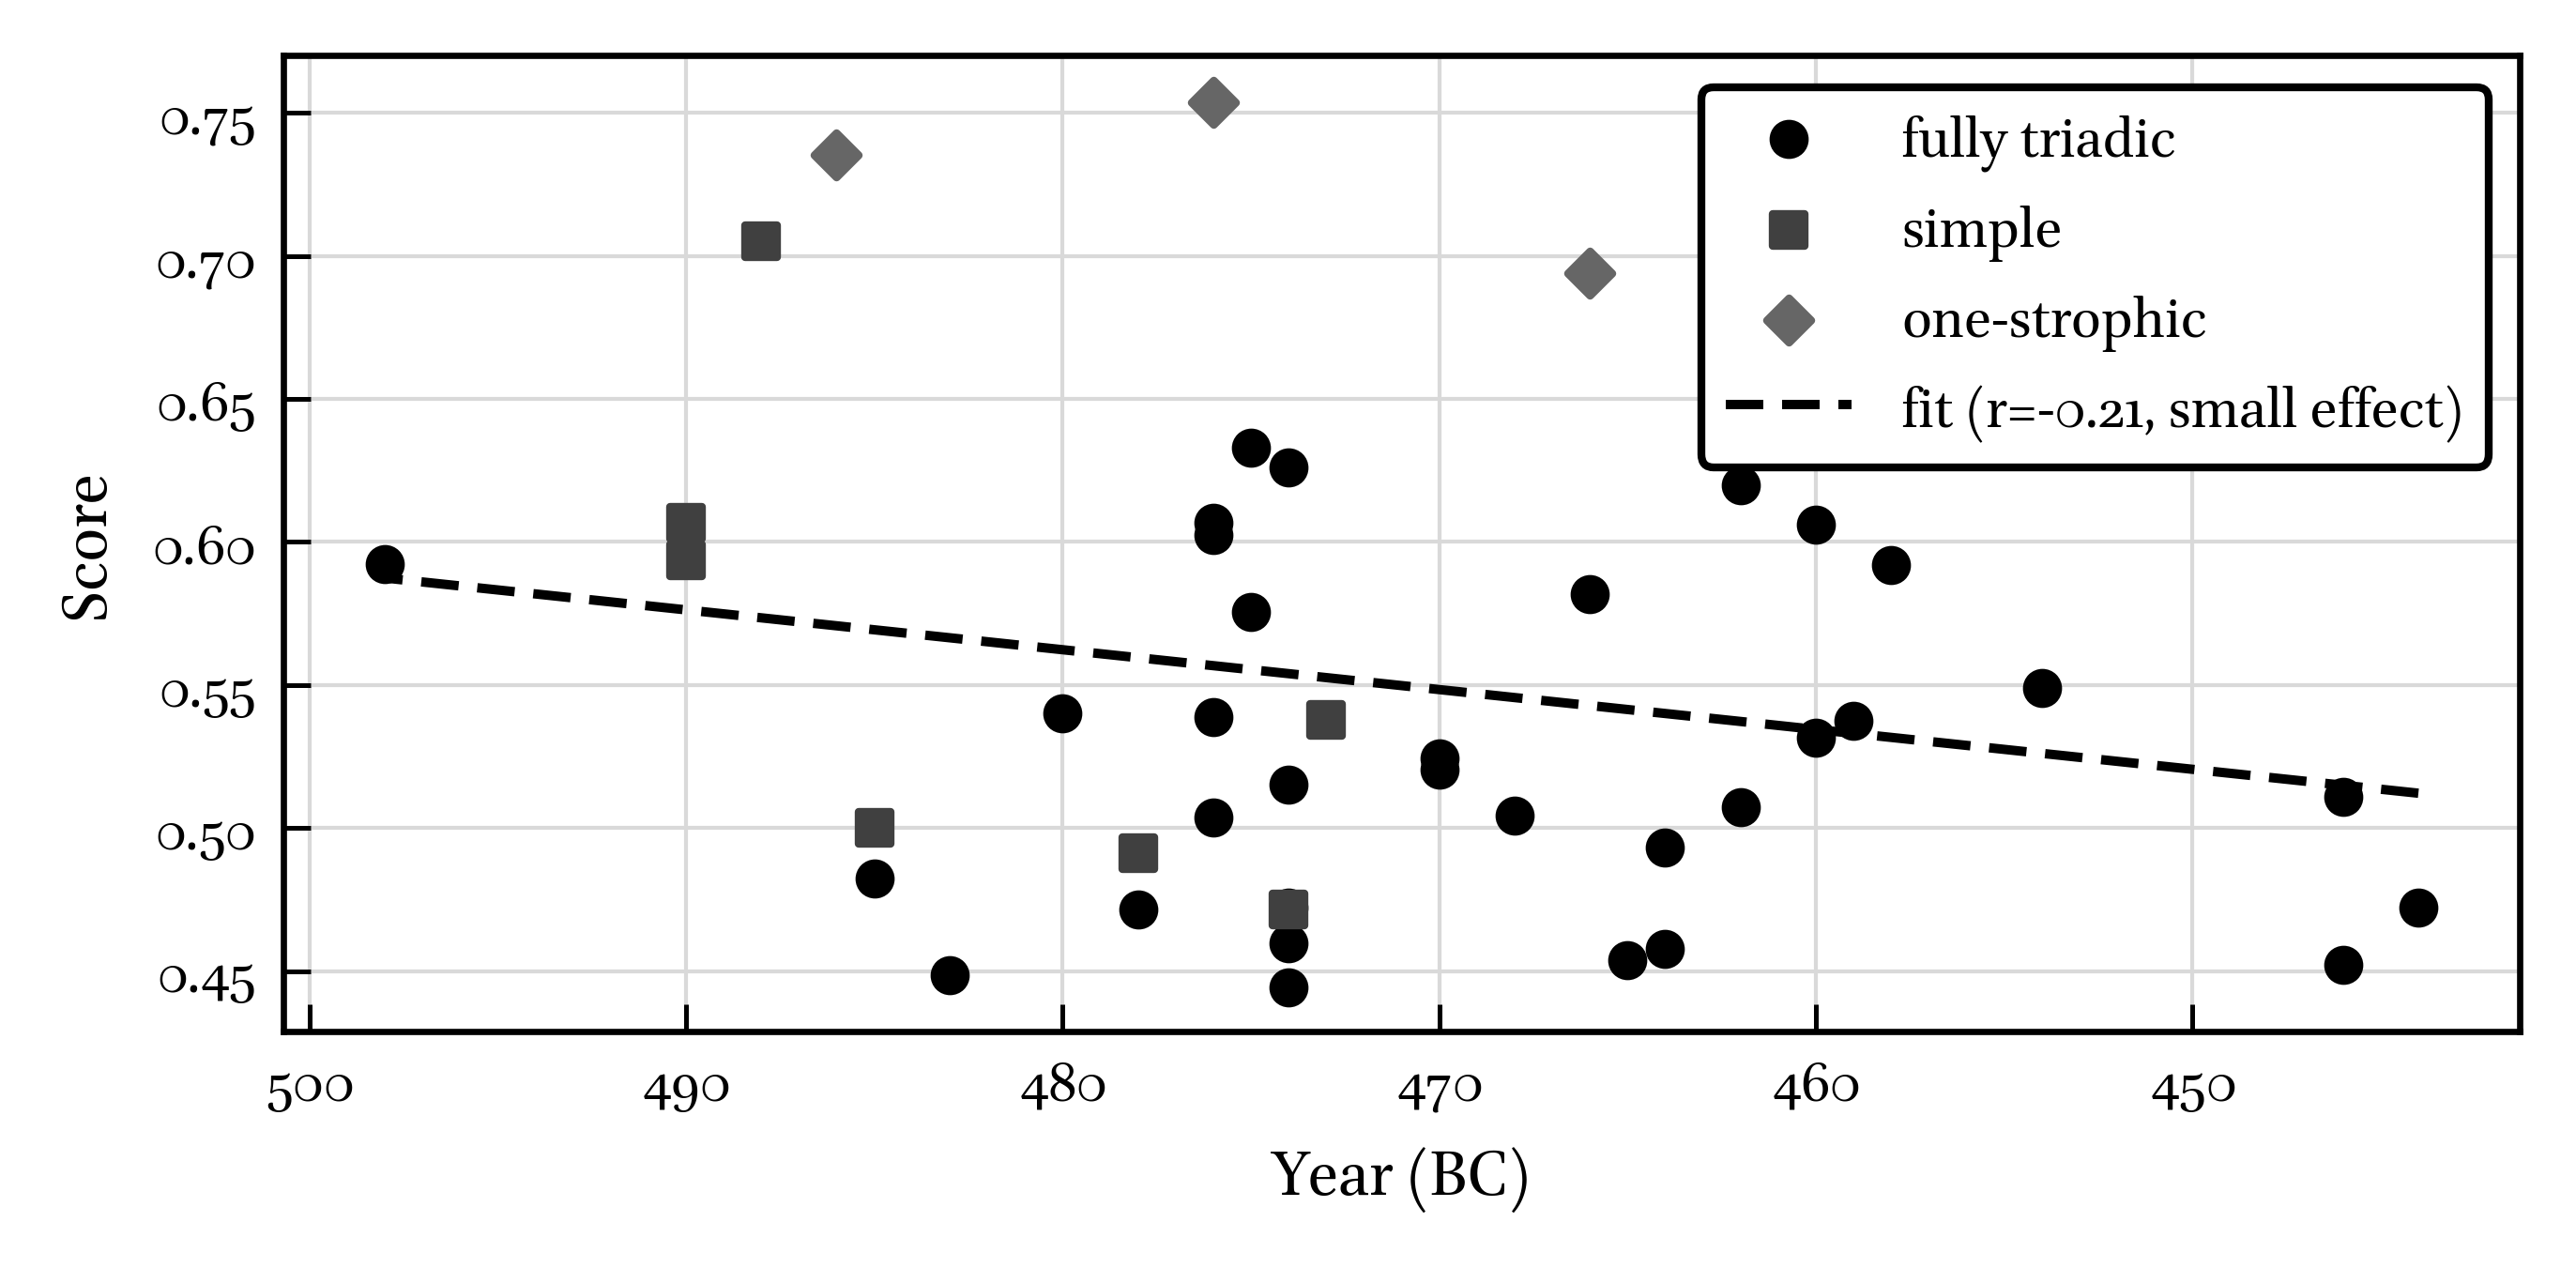

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

from responsio_accentuum import apply_bw_journal_style, MARKERS, sawilowsky_r_size_rules

apply_bw_journal_style(shape="landscape")

fig, ax = plt.subplots()


# --- collect data ---
years_tri, scores_tri = [], []
years_simple, scores_simple = [], []
years_stro, scores_stro = [], []


for ode, score in song_scores_triadic_float.items():
    if ode not in pindar_date_dict:
        continue

    year = pindar_date_dict[ode]

    if ode in fully_triadic_odes:
        years_tri.append(year)
        scores_tri.append(score)
    elif ode in simple_odes:
        years_simple.append(year)
        scores_simple.append(score)


for ode, score in song_scores_one_strophic_float.items():
    if ode not in pindar_date_dict:
        continue

    years_stro.append(pindar_date_dict[ode])
    scores_stro.append(score)


# --- scatter ---
ax.scatter(years_tri, scores_tri, marker=MARKERS[0], label="fully triadic", zorder=3)
ax.scatter(years_simple, scores_simple, marker=MARKERS[1], label="simple", zorder=3)
ax.scatter(years_stro, scores_stro, marker=MARKERS[2], label="one-strophic", zorder=3)


# --- regression ---
all_years = np.array(years_tri + years_simple + years_stro)
all_scores = np.array(scores_tri + scores_simple + scores_stro)

slope, intercept, r, p, stderr = linregress(all_years, all_scores)
sawilowsky_convention = sawilowsky_r_size_rules(r)

x_line = np.linspace(min(all_years), max(all_years), 200)
y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linestyle=(0, (4, 2)),
    linewidth=1.2,
    label=f"fit (r={-r:.2f}, {sawilowsky_convention} effect)",
)


# --- axes ---
ax.set_xlabel("Year (BC)")
ax.set_ylabel("Score")
ax.invert_xaxis()

ax.set_ylim(top=0.77)


# --- legend ---
ax.legend()


plt.tight_layout()
plt.savefig(ROOT / "media" / "figures" / "figure_2_linreg_resp_type.eps")
plt.savefig(ROOT / "media" / "figures" / "figure_2_linreg_resp_type.png")
plt.show()

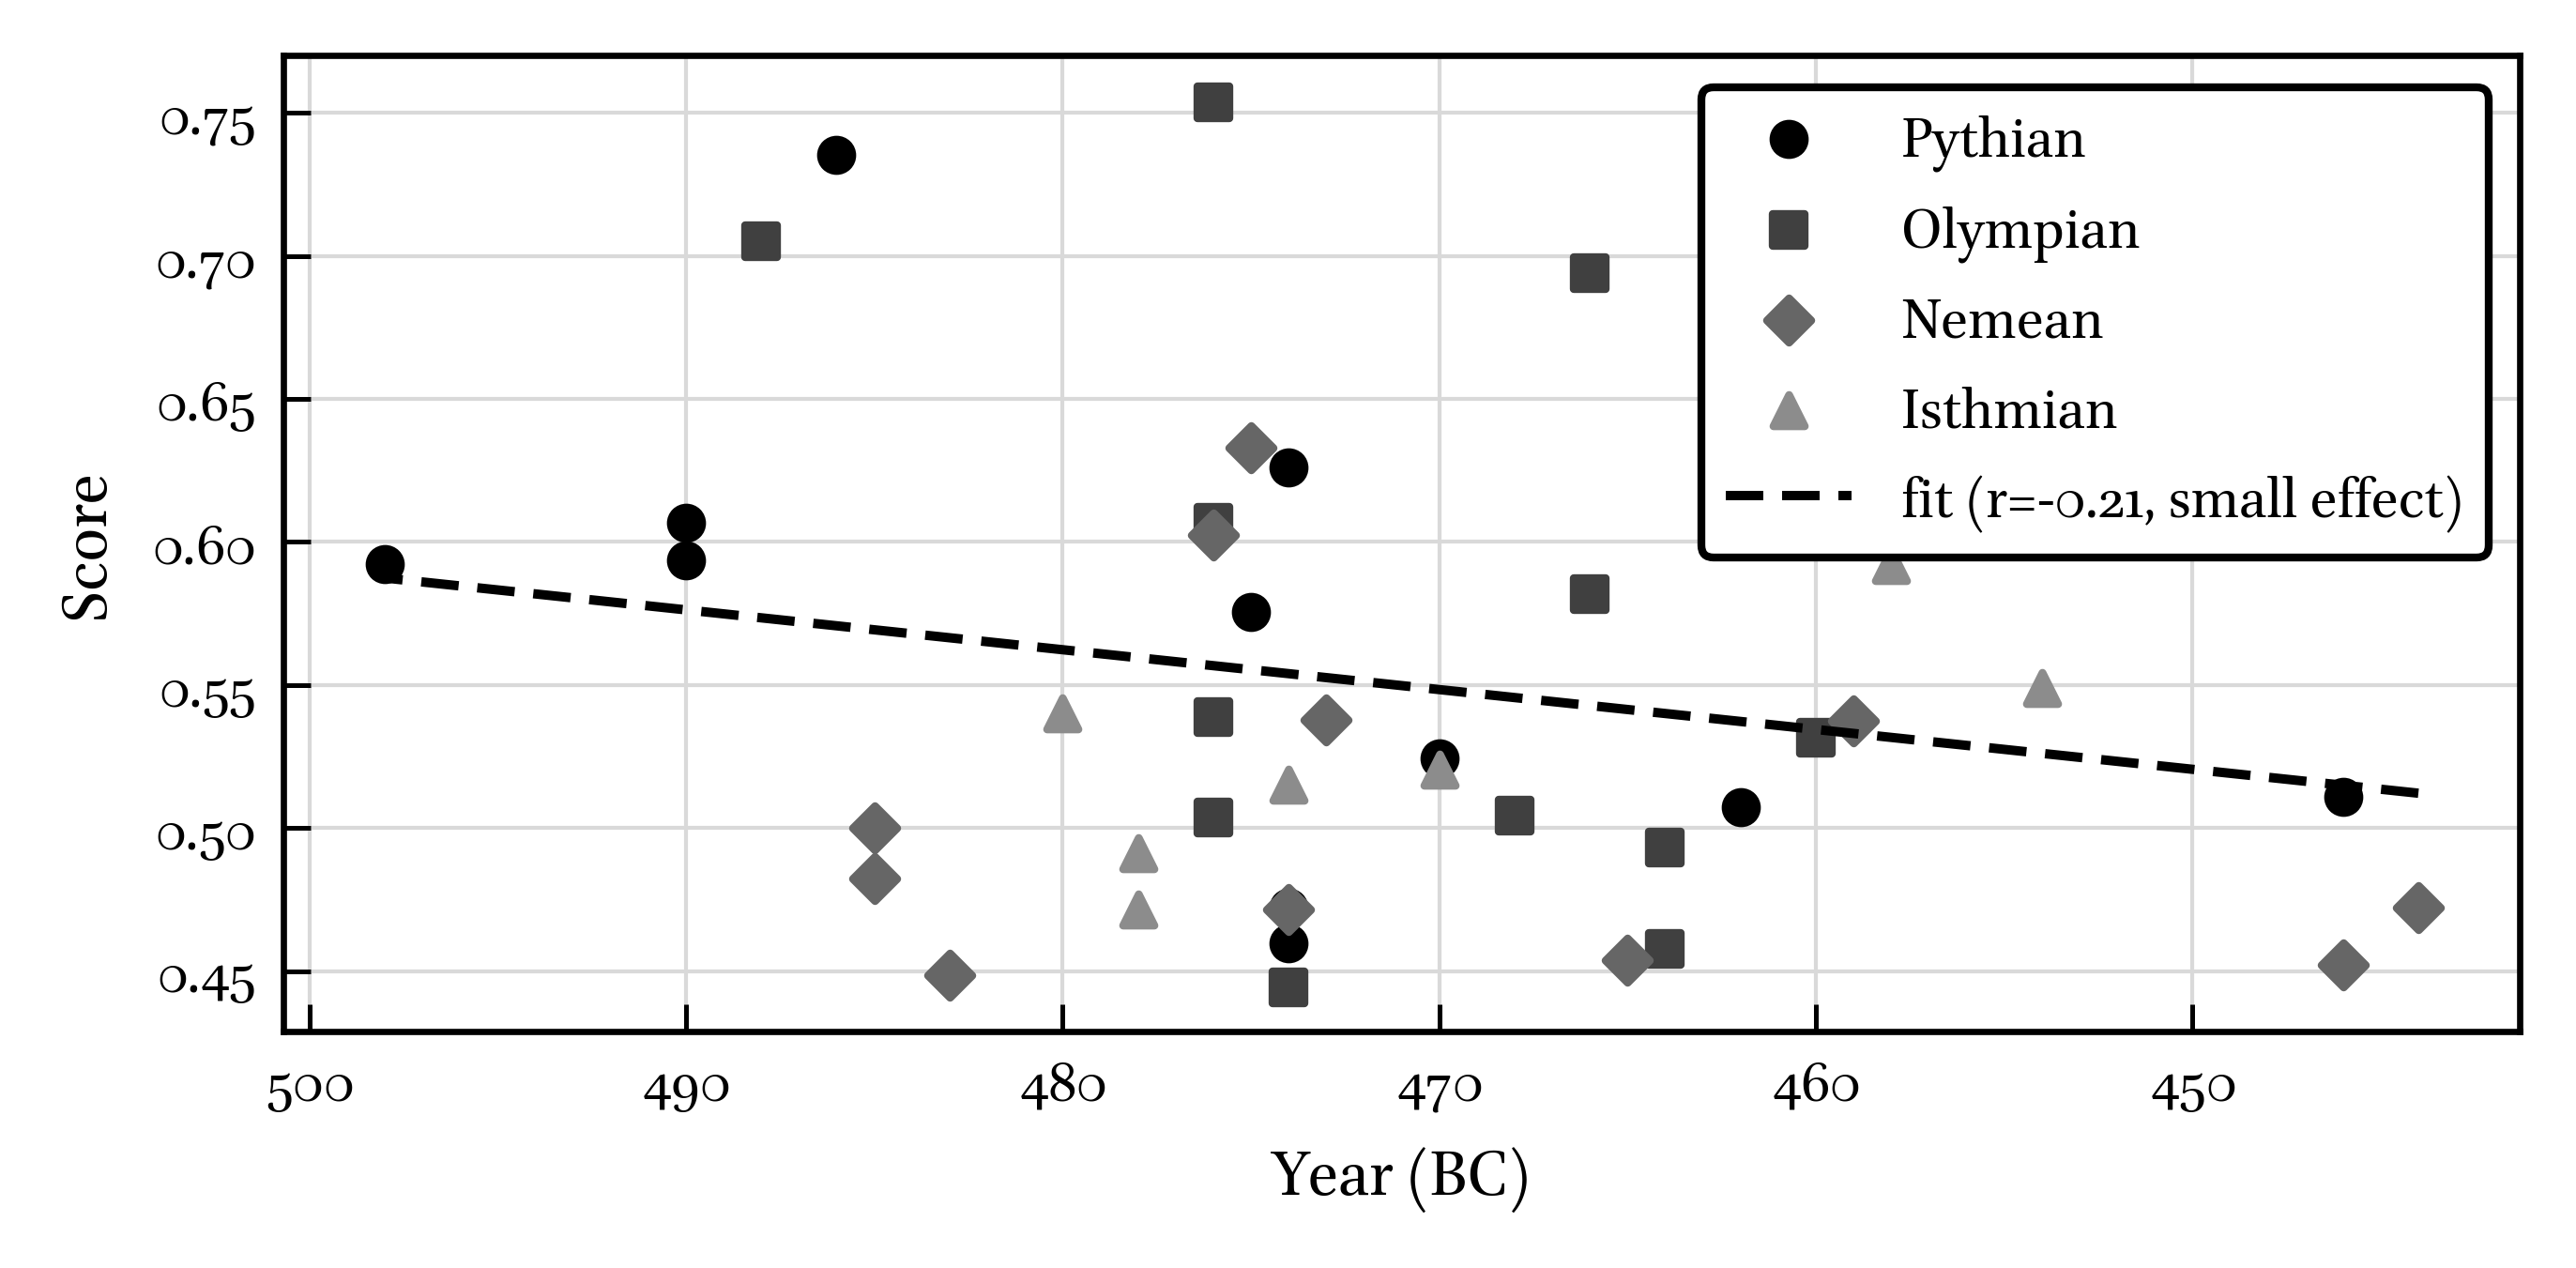

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

from responsio_accentuum import apply_bw_journal_style, MARKERS, sawilowsky_r_size_rules

apply_bw_journal_style(shape="landscape")

fig, ax = plt.subplots()


# --- marker mapping by corpus ---
MARKER_MAP = {
    "py": MARKERS[0],   # circle
    "ol": MARKERS[1],   # square
    "ne": MARKERS[2],   # triangle up
    "is": MARKERS[3],   # diamond
}

# label mapping
LABEL_MAP = {
    "py": "Pythian",
    "ol": "Olympian",
    "ne": "Nemean",
    "is": "Isthmian",
}


# --- collect data grouped by prefix ---
grouped = {
    "py": ([], []),
    "ol": ([], []),
    "ne": ([], []),
    "is": ([], []),
}


def add_point(ode, score):
    if ode not in pindar_date_dict:
        return
    prefix = ode[:2]
    if prefix in grouped:
        year = pindar_date_dict[ode]
        grouped[prefix][0].append(year)
        grouped[prefix][1].append(score)


# triadic + simple
for ode, score in song_scores_triadic_float.items():
    add_point(ode, score)

# one-strophic
for ode, score in song_scores_one_strophic_float.items():
    add_point(ode, score)


# --- scatter (by corpus) ---
for prefix, (years, scores) in grouped.items():
    if not years:
        continue

    marker = MARKER_MAP[prefix]

    ax.scatter(
        years,
        scores,
        marker=marker,
        label=LABEL_MAP[prefix]
    )


# --- regression ---
all_years = np.concatenate([v[0] for v in grouped.values() if v[0]])
all_scores = np.concatenate([v[1] for v in grouped.values() if v[1]])

slope, intercept, r, p, stderr = linregress(all_years, all_scores)
sawilowsky_convention = sawilowsky_r_size_rules(r)

x_line = np.linspace(min(all_years), max(all_years), 200)
y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linestyle=(0, (4, 2)),
    linewidth=1.2,
    color="black",
    label=f"fit (r={-r:.2f}, {sawilowsky_convention} effect)",
)


# --- axes ---
ax.set_xlabel("Year (BC)")
ax.set_ylabel("Score")
ax.invert_xaxis()
ax.set_ylim(top=0.77)


# --- legend ---
ax.legend()


plt.tight_layout()
#plt.savefig(ROOT / "media" / "figures" / "linreg" / "linreg_collection.eps")
#plt.savefig(ROOT / "media" / "figures" / "linreg" / "linreg_collection.svg")
plt.show()

# Scatter comparison (Bacch., Aesch., Soph., Arist.)

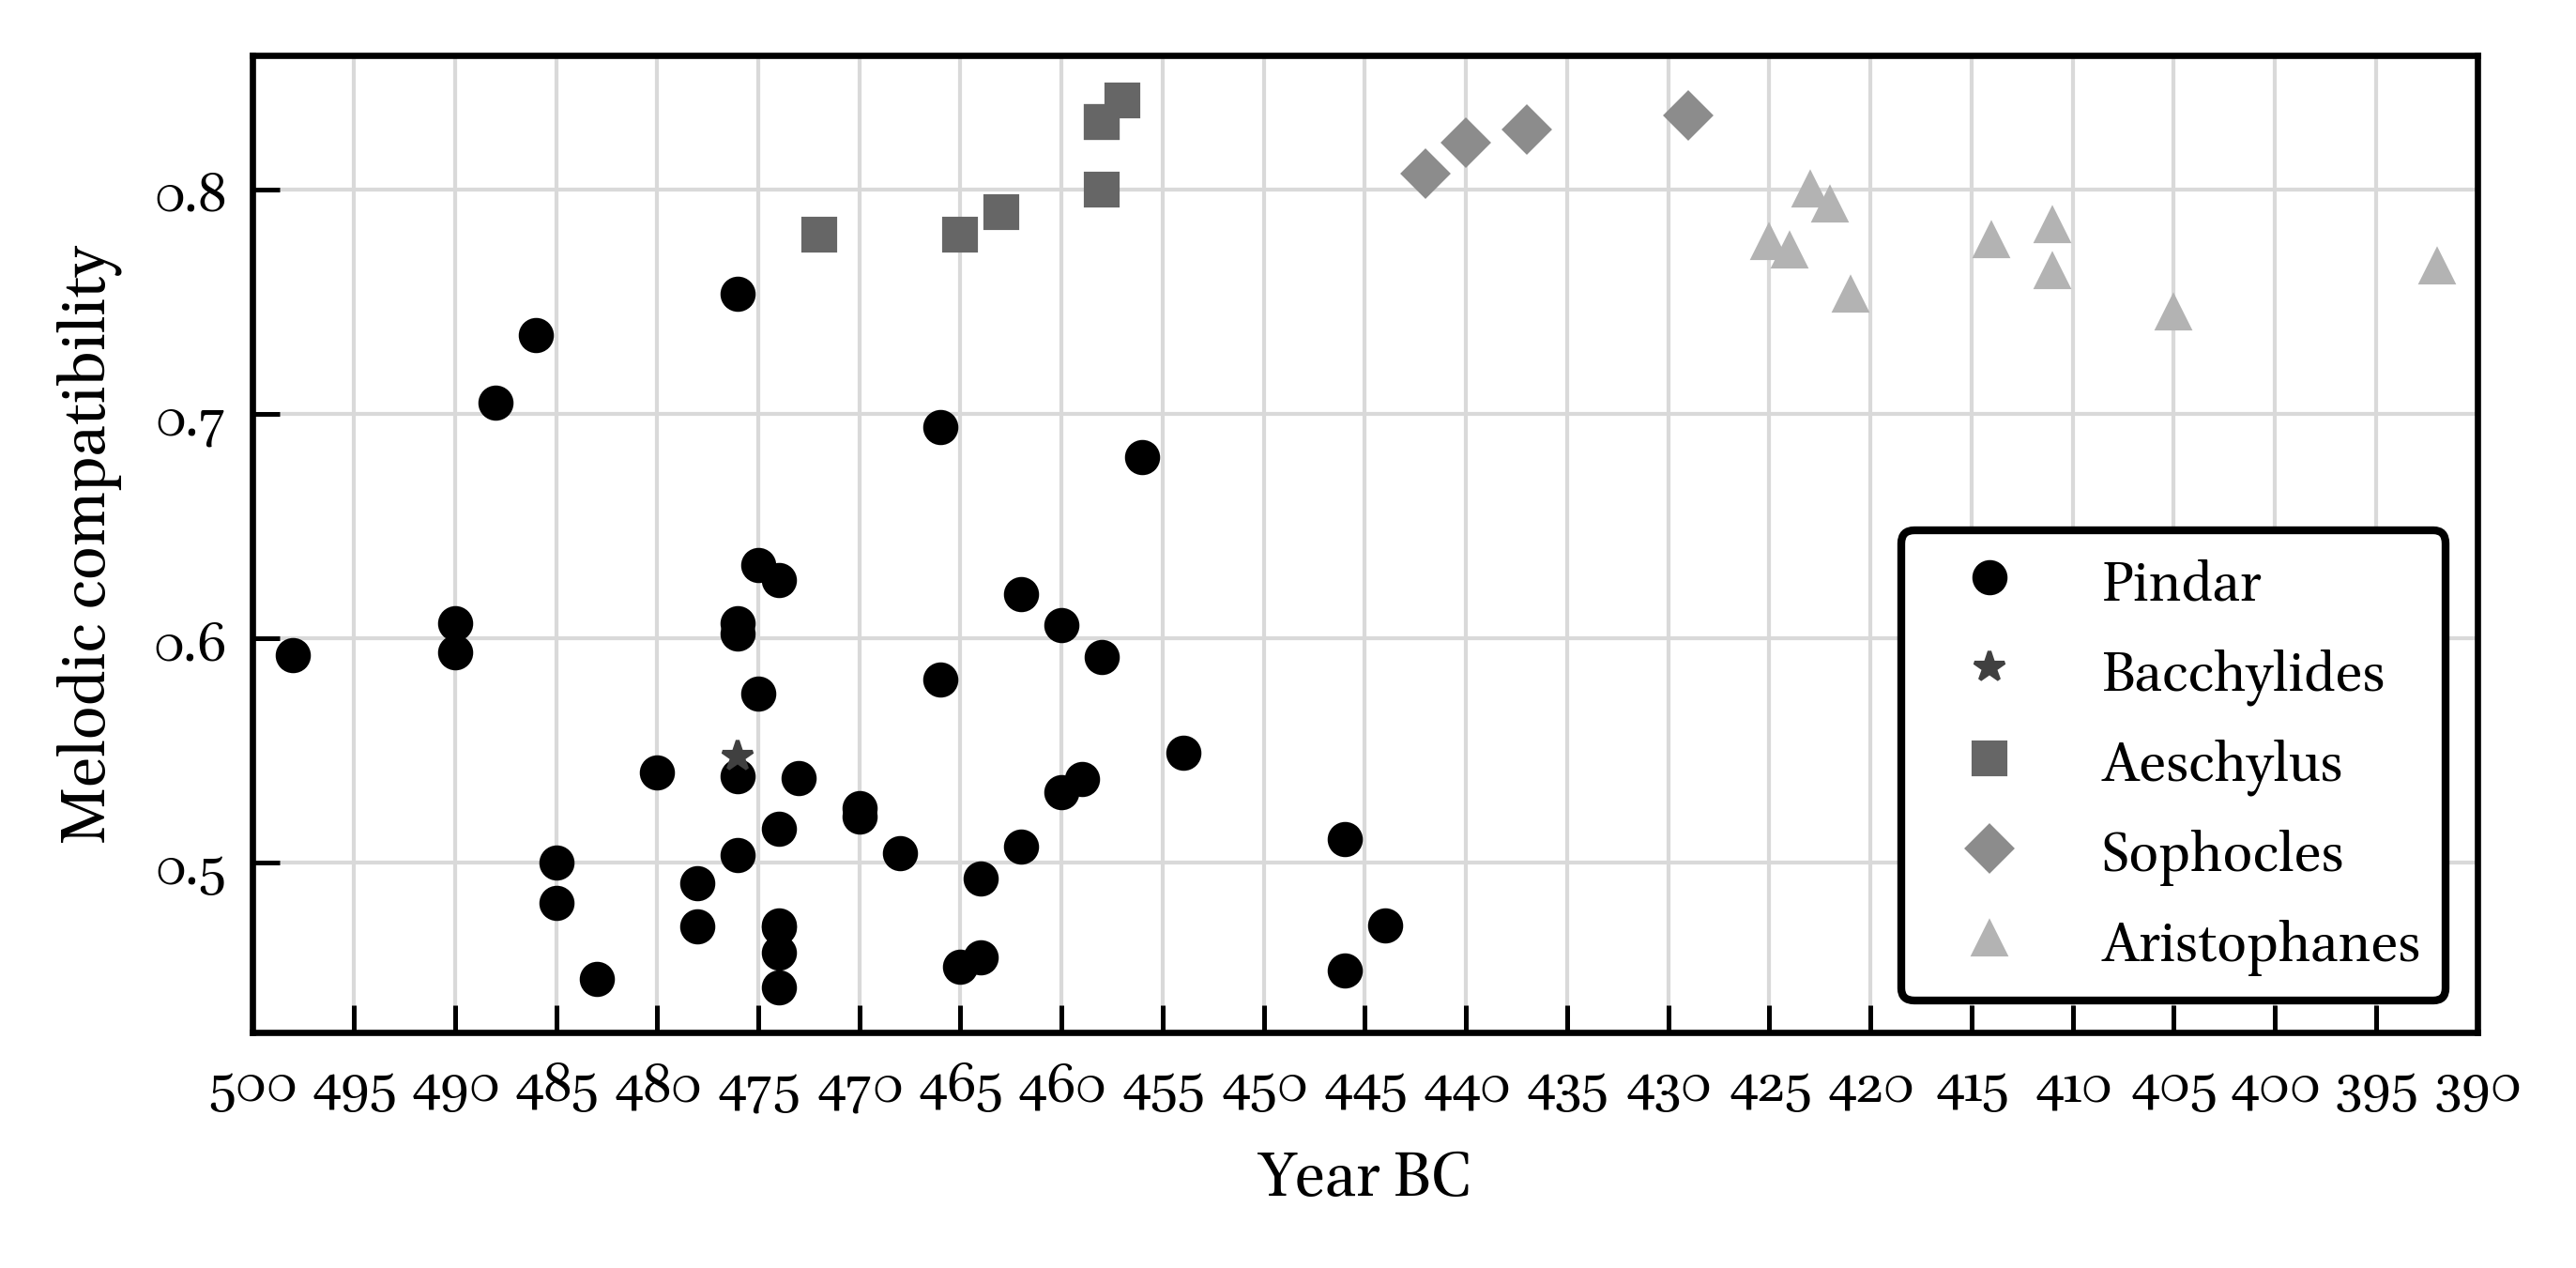

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from responsio_accentuum import (
    apply_bw_journal_style,
    aristophanes_abbreviations_fancy,
    compatibility_canticum, 
    compatibility_ratios_to_stats,
    GRAY_LEVELS,
    MARKERS,
)

apply_bw_journal_style(shape="landscape")
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# ====================================
# Bacchylides
# ====================================

x_ba05 = 476
y_ba05 = compatibility_ratios_to_stats(compatibility_canticum(ROOT / "data/compiled/extra/ba05.xml", "ba05"))

# ====================================
# Pindar # 498 to 444
# ====================================

pindar_scores = {
    **song_scores_triadic_float,
    **song_scores_one_strophic_float,
}

pindar_chronological = sorted(
    (
        (pindar_date_dict[ode], ode, float(score))
        for ode, score in pindar_scores.items()
        if ode in pindar_date_dict
    ),
    reverse=True,
)

labels_pindar = [ode for _, ode, _ in pindar_chronological]

x_pindar = np.array(
    [year for year, _, _ in pindar_chronological],
    dtype=float,
)

y_pindar = np.array(
    [score for _, _, score in pindar_chronological],
    dtype=float,
)

# ====================================
# Aristophanes # 425 to 392
# ====================================

plays_aristophanes = {
    "ach": 0.7766736401673641,
    "eq": 0.7729885057471264,
    "nu": 0.8,
    "v": 0.7933168316831684,
    "pax": 0.7533834586466165,
    "av": 0.7776332899869961,
    "lys": 0.7843406593406593,
    "th": 0.7635467980295566,
    "ra": 0.7452267303102625,
    "ec": 0.7657142857142857,
}

aristophanes_date_dict = {
    "ach": 425,
    "eq": 424,
    "nu": 423,
    "v": 422,
    "pax": 421,
    "av": 414,
    "lys": 411,
    "th": 411,
    "ra": 405,
    "ec": 392,  # 393/2
}

labels_ar = [
    aristophanes_abbreviations_fancy.get(k, k)
    for k in plays_aristophanes.keys()
]

x_ar = np.array(
    [aristophanes_date_dict[k] for k in plays_aristophanes],
    dtype=float,
)

y_ar = np.array(
    [float(v) for v in plays_aristophanes.values()],
    dtype=float,
)

# ====================================
# Aeschylus # 472 to ?
# ====================================

plays_ae = [
    "Pers.",  # 472
    "Th.",
    "Supp.",
    "Ag.",  # 458
    "Ch.",  # 458
    "Eu.",  # 458
    "Pr.",
]

aeschylus_date_dict = {
    "Pers.": 472,
    "Th.": 465,
    "Supp.": 463,
    "Ag.": 458,
    "Ch.": 458,
    "Eu.": 458,
    "Pr.": 457,
}

x_ae = np.array(
    [aeschylus_date_dict[p] for p in plays_ae],
    dtype=float,
)

y_ae = np.array(
    [0.78, 0.78, 0.79, 0.80, 0.83, 0.83, 0.84],
    dtype=float,
)

# ====================================
# Sophocles # 450? to 429?
# ====================================

plays_sophocles = [
    "Ant.",
    "Aj.",
    "Tr.",
    "OT",
]

sophocles_date_dict = {
    "Ant.": 442,
    "Aj.": 440,
    "Tr.": 437,
    "OT": 429,
}

x_soph = np.array(
    [sophocles_date_dict[p] for p in plays_sophocles],
    dtype=float,
)

y_sophocles = np.array(
    [0.807, 0.821, 0.827, 0.833],
    dtype=float,
)

# ====================================
# Figure
# ====================================
fig, ax = plt.subplots()

# Pindar
ax.plot(
    x_pindar,
    y_pindar,
    marker=MARKERS[0],
    linestyle="None",
    label="Pindar",
    zorder=3
)

# Bacchylides
ax.plot(
    x_ba05,
    y_ba05,
    marker=MARKERS[7],
    linestyle="None",
    label="Bacchylides",
    zorder=3
)

# Aeschylus
ax.plot(
    x_ae,
    y_ae,
    marker=MARKERS[1],
    linestyle="None",
    label="Aeschylus",
    zorder=3
)

# Sophocles
ax.plot(
    x_soph,
    y_sophocles,
    marker=MARKERS[2],
    linestyle="None",
    label="Sophocles",
    zorder=3
)

# Aristophanes
ax.plot(
    x_ar,
    y_ar,
    marker=MARKERS[3],
    linestyle="None",
    label="Aristophanes",
    zorder=3
)

# ====================================
# X-axis
# ====================================

# Chronological axis
all_x = np.concatenate([x_pindar, [x_ba05], x_ae, x_soph, x_ar])

tick_years = np.arange(
    390,
    501,
    5,
)

ax.set_xticks(tick_years)
ax.set_xlim(500, 390)

ax.set_xlabel("Year BC")

# ====================================
# Y-axis
# ====================================
ax.set_ylabel("Melodic compatibility")

# ====================================
# Style
# ====================================
ax.grid(True, which="major", axis="both")
ax.legend(
    loc="lower right",
    framealpha = 1.0 # postscript (.eps) does not support transparency
)

plt.tight_layout()

plt.savefig(ROOT / "media/figures/figure_3_scatter_four_poets.eps")
plt.savefig(ROOT / "media/figures/figure_3_scatter_four_poets.png", dpi=600)

plt.show()